# 1. Set up

In [1]:
!pip install pandas
!pip install scikit-learn
!pip install pyarrow
!pip install category_encoders scikit-plot
!pip install pyproj
!pip install seaborn
!pip install shap

# 2. Import necessary libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

import torch.nn as nn

import category_encoders as ce
from sklearn.metrics import (
    roc_auc_score, roc_curve,confusion_matrix, classification_report, precision_recall_curve, auc, recall_score, precision_score,
    f1_score
)
from pyproj import Transformer
import shap
from tqdm import tqdm

from utils import *

c:\Users\GAZARAGOZAG-local\Documents\UFD\Repo_2\ufd-dataia-deteccion-fraude\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 3. Define global variables

we will be using march as the training month and april as the validation month

In [3]:
# INPUT_X_PATH = "../data/output_data/data_training_june.csv"
# INPUT_X_EVAL_PATH = "../data/output_data/data_validation_august.csv"
# INPUT_Y_EVAL_PATH = "../data/output_data/data_validation_august_y.csv"
# INPUT_Y_PATH = "../data/output_data/data_training_june_y.csv"

INPUT_X_PATH = "../data/output_data/data_training_june.csv"
INPUT_X_EVAL_PATH = "../data/output_data/data_validation_test.csv"
# INPUT_Y_EVAL_PATH = "../data/output_data/data_validation_august_y.csv"
INPUT_Y_PATH = "../data/output_data/data_training_june_y.csv"


INPUT_FINAL_DF_PATH  = "../data/output_data/final_df_non_supervised_sept.csv"
INPUT_FINAL_DF_EVAL_PATH  = "../data/output_data/final_df_eval_non_supervised_sept.csv"

In [4]:
OUTPUT_FEATURE_IMPORTANCE_RF = "../powerbi/feature_importance_rf_sept.csv"

In [5]:
target_col = "target"

Let's define some colors for the viz we will be doing

In [6]:
ufd_orange = "#f26122"
ufd_blue = "#003865"
ufd_gray = "#cccccc"

# 4. Functions

# 5. Code

## 5.1. Data loading

We will load the data, both the training and the validation data

In [ ]:
X = pd.read_csv(INPUT_X_PATH, sep=";")
y = pd.read_csv(INPUT_Y_PATH, sep=";")[target_col]
X_eval = pd.read_csv(INPUT_X_EVAL_PATH, sep=";")
# y_eval = pd.read_csv(INPUT_Y_EVAL_PATH, sep=";")[target_col]

final_df = pd.read_csv(INPUT_FINAL_DF_PATH, sep=";")
final_df_eval = pd.read_csv(INPUT_FINAL_DF_EVAL_PATH, sep=";")

NameError: name 'INPUT_Y_EVAL_PATH' is not defined

In [ ]:
X.head(5)

,porcentaje_calidad_datos_trimestre_actual_incorrectos,consumo_zero_anio_anterior,consumo_zero_anio_actual,porcentaje_calidad_datos_anio_actual_incorrectos,consumo_zero_mes_anio_pasado,consumo_zero_mes_actual,consumo_zero_trimestre_anio_pasado,consumo_min_anio_actual,consumo_min_anio_anterior,consumo_zero_trimestre_actual,...,consumo_stddev_trimestre_anio_pasado,porcentaje_calidad_datos_mes_actual_incorrectos,consumo_suma_mes_anio_pasado,consumo_max_trimestre_pasado,consumo_stddev_semana_pasada,consumo_suma_mes_pasado,consumo_stddev_semana_anio_pasado,consumo_max_semana_pasada,cnt_inspecciones_anio_actual,consumo_umbral_mes_actual
0,0.09,0.0,0.0,0.06,0.0,0.0,0.0,30.0,2.0,0.0,...,308.36,0.00,277518.0,3355.0,218.41,225479.0,267.09,1455.0,84.0,705.0
1,0.50,0.0,0.0,0.24,0.0,0.0,0.0,116.0,129.0,0.0,...,2399.26,0.42,1000000.0,15333.0,2397.68,1000000.0,2500.03,10384.0,28.0,717.0
2,0.18,0.0,0.0,0.07,0.0,0.0,0.0,197.0,0.0,0.0,...,0.00,0.00,0.0,20019.0,738.45,1000000.0,0.00,4456.0,54.0,720.0
3,0.09,0.0,0.0,0.02,0.0,0.0,0.0,1.0,1.0,0.0,...,214.88,0.00,64592.0,1909.0,21.07,74252.0,140.30,101.0,28.0,25.0
4,0.09,0.0,0.0,0.02,0.0,0.0,0.0,853.0,1248.0,0.0,...,5201.35,0.00,1000000.0,3084.0,15878.61,1000000.0,6003.34,123703.0,0.0,720.0


In [ ]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [col for col in cat_cols if col not in ['cups_sgc', 'cnt_id', target_col]]

## 5.2. Supervised learning

In [9]:
X.fillna(0, inplace=True)
y.fillna(0, inplace=True)

X_eval.fillna(0, inplace=True)
# y_eval.fillna(0, inplace=True) 

### 5.2.1. Modelling

Realizamos un target encoding a aquellas variables que sean categóricas en nuestro dato:

In [11]:
encoder = ce.TargetEncoder(cols=cat_cols)
X_train_enc = encoder.fit_transform(X, y)
# X_test_enc = encoder.transform(X_test)

Finalmente definimos el modelo y lo entrenamos

In [12]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
)

model.fit(X_train_enc, y)


,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 5.2.2. Metrics extraction

Para poder calcular las métricas, en primer lugar debemos calcular las predicciones

In [13]:
y_proba = model.predict_proba(X_train_enc)[:, 1] 
y_pred = model.predict(X_train_enc)

Primeramente pintaremos la curva ROC junto con su valor de AUC

In [14]:
auc_df = compute_individual_auc(X, y, target_col="target")

print(auc_df.head(15))

Computing AUCs: 100%|██████████| 75/75 [00:00<00:00, 207.34it/s]

                                              feature       auc
0    porcentaje_calidad_datos_anio_actual_incorrectos  0.900534
1   porcentaje_calidad_datos_trimestre_actual_inco...  0.891138
2                            consumo_zero_anio_actual  0.736544
3                          consumo_zero_anio_anterior  0.711898
4                       consumo_zero_trimestre_actual  0.663739
5   porcentaje_calidad_datos_trimestre_actual_corr...  0.642457
6   porcentaje_calidad_datos_mismo_trimestre_anio_...  0.640826
7   porcentaje_calidad_datos_mismo_mes_anio_pasado...  0.637391
8       porcentaje_calidad_datos_mes_pasado_correctos  0.628565
9                       consumo_zero_trimestre_pasado  0.628045
10                 consumo_zero_trimestre_anio_pasado  0.626346
11  porcentaje_calidad_datos_misma_semana_anio_pas...  0.622998
12      porcentaje_calidad_datos_mes_actual_correctos  0.619288
13   porcentaje_calidad_datos_semana_actual_correctos  0.612131
14   porcentaje_calidad_datos_semana_pas

In [15]:
auc_df = compute_individual_auc(X_eval, y_eval, target_col="target")

print(auc_df.head(15))

Computing AUCs: 100%|██████████| 75/75 [00:00<00:00, 198.17it/s]

                                              feature       auc
0    porcentaje_calidad_datos_anio_actual_incorrectos  0.899183
1   porcentaje_calidad_datos_trimestre_pasado_inco...  0.889408
2                            consumo_zero_anio_actual  0.731806
3                          consumo_zero_anio_anterior  0.707547
4                       consumo_zero_trimestre_pasado  0.644205
5   porcentaje_calidad_datos_trimestre_pasado_corr...  0.639187
6   porcentaje_calidad_datos_misma_semana_anio_pas...  0.636707
7   porcentaje_calidad_datos_mismo_trimestre_anio_...  0.635984
8   porcentaje_calidad_datos_mismo_mes_anio_pasado...  0.623144
9    porcentaje_calidad_datos_semana_actual_correctos  0.620052
10                      consumo_zero_trimestre_actual  0.619946
11   porcentaje_calidad_datos_semana_pasada_correctos  0.618504
12      porcentaje_calidad_datos_mes_actual_correctos  0.614334
13                            consumo_zero_mes_actual  0.603774
14                 consumo_zero_trimestr

In [16]:
final_df["target"].value_counts(normalize=True)

target
0.0    0.954379
1.0    0.045621
Name: proportion, dtype: float64

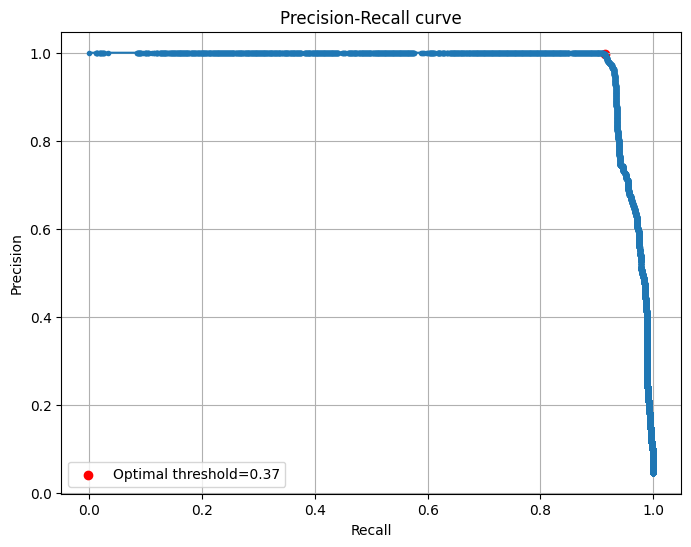

In [17]:
thres_train, _ = find_optimal_thres(y, y_proba)

### 5.2.3. Predictions calibration

In [18]:
calibrated_model = CalibratedClassifierCV(estimator=model,
                                          method="isotonic", cv=5)
calibrated_model.fit(X, y)

proba_cal_val = calibrated_model.predict_proba(X_eval)[:,1]

In [19]:
# ejemplo de costes
C_FN = 1000  # coste de dejar pasar un fraude
C_FP = 50    # coste de investigar un inocente

best_cost, best_thr, FN, FP = find_cost_optimal_threshold(y_eval, proba_cal_val, C_FN, C_FP)
print(f"Umbral coste-óptimo: {best_thr:.3f} (Coste esperado: {best_cost}, FN={FN}, FP={FP})")


Umbral coste-óptimo: 0.070 (Coste esperado: 79950, FN=25, FP=1099)


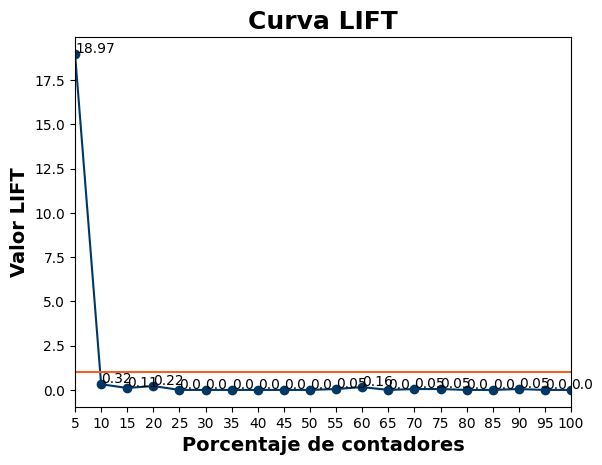

In [20]:
def plot_lift(y_true, proba, bins=20):
    df = pd.DataFrame({"y": y_true, "proba": proba})
    df = df.sort_values("proba", ascending=False).reset_index(drop=True)
    df["bucket"] = pd.qcut(df.index, bins, labels=False)

    lift_table = df.groupby("bucket").agg(
        n=("y","size"),
        frauds=("y","sum"),
        avg_score=("proba","mean")
    ).reset_index()

    lift_table["fraud_rate"] = lift_table["frauds"] / lift_table["n"]
    global_rate = df["y"].mean()
    lift_table["lift"] = lift_table["fraud_rate"] / global_rate
    lift_table["cum_frauds"] = lift_table["frauds"].cumsum()
    lift_table["cum_frauds_pct"] = lift_table["cum_frauds"] / df["y"].sum()

    plt.figure(figsize=(8,6))
    plt.plot(np.linspace(0,100,bins), lift_table["cum_frauds_pct"]*100, marker='o')
    plt.xlabel("% población (ordenada por score)")
    plt.ylabel("% fraudes capturados (acumulado)")
    plt.title("Curva Lift acumulada (modelo supervisado)")
    plt.grid(True)
    plt.show()

    return lift_table

lift_table = lift_chart_plot(y_eval, proba_cal_val, num_chunks=20)


In [21]:
y_pred = (y_proba >= thres_train).astype(int)

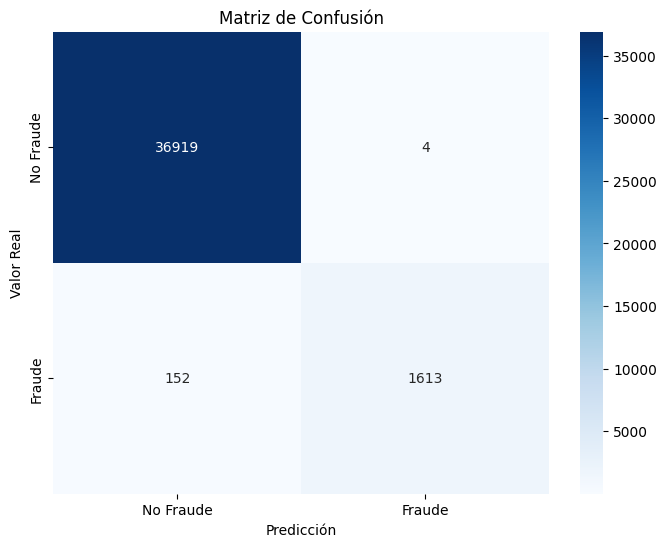


Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     36923
         1.0       1.00      0.91      0.95      1765

    accuracy                           1.00     38688
   macro avg       1.00      0.96      0.98     38688
weighted avg       1.00      1.00      1.00     38688



In [22]:
cm = confusion_matrix(y, y_pred)
# Crear una visualización más clara
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fraude', 'Fraude'],
            yticklabels=['No Fraude', 'Fraude'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()
 
# También puedes mostrar el reporte de clasificación completo
print("\nReporte de Clasificación:")
print(classification_report(y, y_pred))

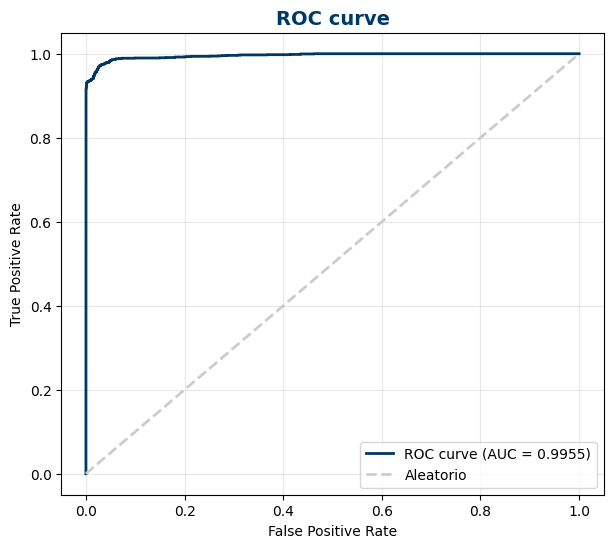

ROC AUC Score: 0.9955


In [23]:
fpr, tpr, thresholds = roc_curve(y, y_proba)
roc_auc = roc_auc_score(y, y_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color=ufd_blue, lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color=ufd_gray, lw=2, linestyle="--", label="Aleatorio")

# Estilo
plt.grid(alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve", fontsize=14, weight="bold", color=ufd_blue)
plt.legend(loc="lower right", fontsize=10)
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

Let's see also gain and lift curves

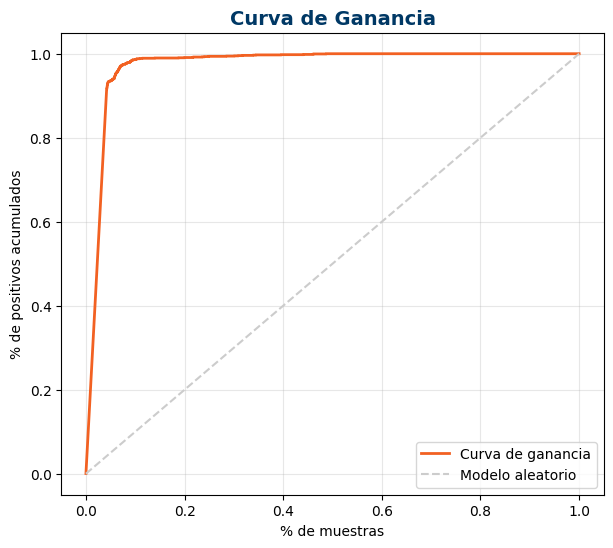

In [24]:
plot_gain(y, y_proba)

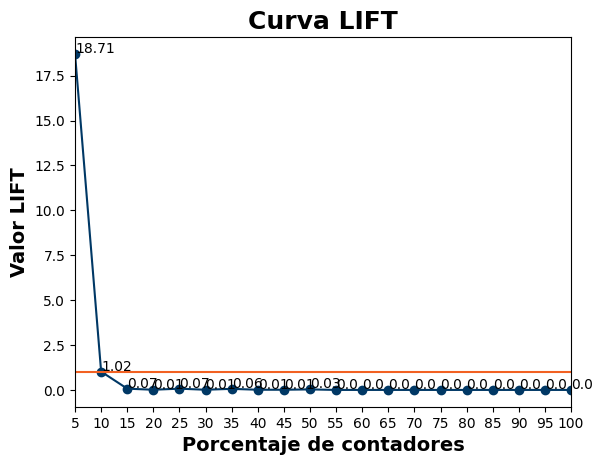

In [25]:
lift_chart_plot(y, y_proba, num_chunks=20)

In [26]:
final_df["target"].value_counts()

target
0.0    36923
1.0     1765
Name: count, dtype: int64

In [27]:
# # First, get the indices of the test set in final_df
# test_indices = X_test.index
# train_indices = X_train.index

# # Assign the predicted probabilities to the correct rows
# final_df.loc[test_indices, "xgb_pred_proba"] = y_proba
# final_df.loc[train_indices, "xgb_pred_proba"] = y_proba_train

# final_df.loc[test_indices, "train"] = 0
# final_df.loc[train_indices, "train"] = 1

In [28]:
final_df["pred_proba"] = y_proba

In [29]:
final_df["final_scoring"] = final_df["fraude_score_no_supervisado"]*0.3 + final_df["pred_proba"]*0.7

We define the cuts attending to the lift chart previously defined:

In [30]:
cuts = [25, 35]  
thresholds = get_probability_thresholds(y, y_proba, cuts)

print("Thresholds:", thresholds)

Thresholds: [0.013383769811469272, 0.011060284754595275]


We create the new cateogria_fraude column used to order the probabilistic results of the fraud

In [31]:
conditions = [
    final_df["final_scoring"] < thresholds[0],                             
    (final_df["final_scoring"] >= thresholds[0]) & (final_df["final_scoring"] < thresholds[1]),  
    final_df["final_scoring"] >= thresholds[1]                             
]

choices = ["Bajo", "Medio", "Alto"]

final_df["categoria_fraude"] = np.select(conditions, choices, default="Bajo")

### 5.4.3. Feature importance

In [32]:
importancias = model.feature_importances_
features = X.columns

df_importancia = pd.DataFrame({
    'feature': features,
    'importance': importancias
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

df_importancia.head(10)

,feature,importance
0,porcentaje_calidad_datos_trimestre_actual_inco...,0.190918
1,consumo_zero_anio_actual,0.151080
2,porcentaje_calidad_datos_anio_actual_incorrectos,0.092867
3,consumo_zero_anio_anterior,0.085299
4,consumo_zero_trimestre_anio_pasado,0.059275
5,consumo_zero_trimestre_pasado,0.043176
6,consumo_zero_trimestre_actual,0.038355
7,consumo_zero_mes_actual,0.034120
8,porcentaje_calidad_datos_trimestre_pasado_corr...,0.033321
9,consumo_min_anio_actual,0.019960


Let's save this data frame into the powerbi folder. We will use then this data to show it in the dashboard

In [33]:
df_importancia.head(10).to_csv(OUTPUT_FEATURE_IMPORTANCE_RF, sep=";", decimal=",")

## 5.3. Evaluating the model

We are going to use the previously trained model to test it in the april data for example. Thus, let's go for it

In [34]:
for col in X:
    if col not in X_eval:
        X_eval[col] = 0

In [35]:
y_proba_eval = model.predict_proba(X_eval[X.columns])[:, 1] 
y_pred_eval = model.predict(X_eval[X.columns]) # threshold 0.5

In [36]:
final_df_eval["pred_proba"] = y_proba_eval
final_df_eval["final_scoring"] = final_df_eval["fraude_score_no_supervisado"]*0.3 + final_df_eval["pred_proba"]*0.7

In [37]:
thresholds_val = get_probability_thresholds(y_eval, final_df_eval["final_scoring"], cuts)

conditions_val = [
    final_df_eval["final_scoring"] < thresholds_val[0],                             
    (final_df_eval["final_scoring"] >= thresholds_val[0]) & (final_df_eval["final_scoring"] < thresholds_val[1]),  
    final_df_eval["final_scoring"] >= thresholds_val[1]                             
]

final_df_eval["categoria_fraude"] = np.select(conditions_val, choices, default="Bajo")

In [38]:
final_df_eval["categoria_fraude"].value_counts()

categoria_fraude
Bajo    29817
Alto     9940
Name: count, dtype: int64

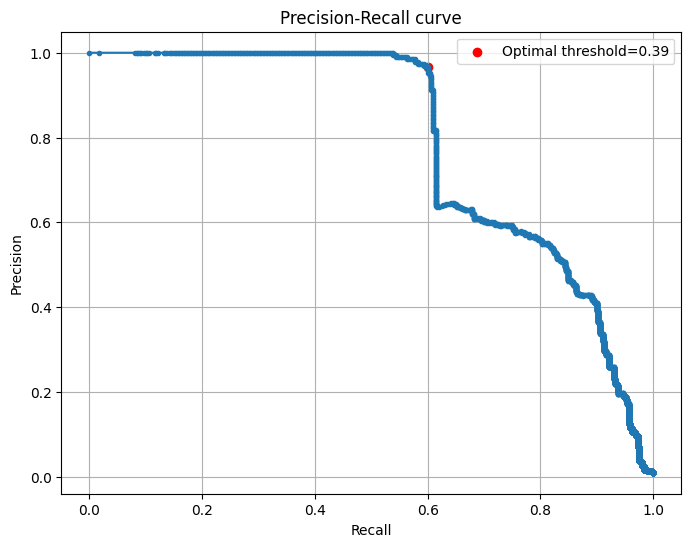

In [39]:
thres_val, _ = find_optimal_thres(y_eval, y_proba_eval)

Let's define the prediction array making use of the extracted threshold

In [40]:
y_pred_eval = (y_proba_eval >= thres_val).astype(int)
y_pred_eval = (y_proba_eval >= thres_train).astype(int)

In [53]:
thres_val

np.float64(0.39001855036498717)

In [54]:
thres_train

np.float64(0.3742218226484973)

If we show the confusion matrix:

In [41]:
model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 5,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

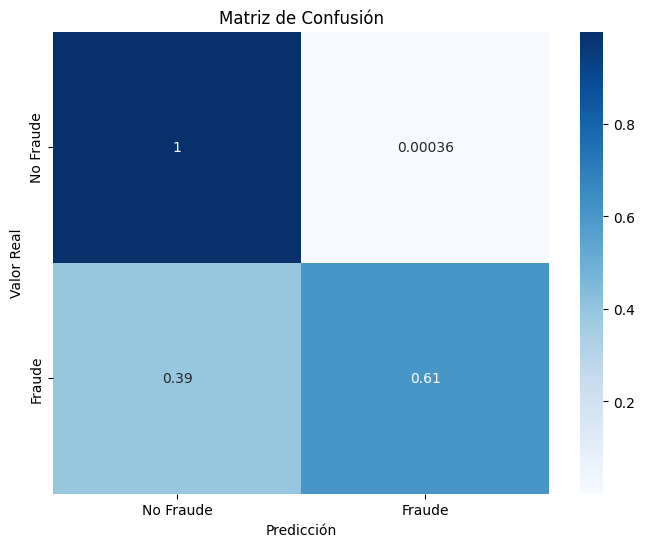


Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     39386
         1.0       0.94      0.61      0.74       371

    accuracy                           1.00     39757
   macro avg       0.97      0.80      0.87     39757
weighted avg       1.00      1.00      1.00     39757

0.7377049180327869


In [42]:
cm = confusion_matrix(y_eval, y_pred_eval, normalize="true")
# Crear una visualización más clara
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues',
            xticklabels=['No Fraude', 'Fraude'],
            yticklabels=['No Fraude', 'Fraude'], )
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()
 
# También puedes mostrar el reporte de clasificación completo
print("\nReporte de Clasificación:")
print(classification_report(y_eval, y_pred_eval))

print(f1_score(y_eval, y_pred_eval))

Primeramente pintaremos la curva ROC junto con su valor de AUC

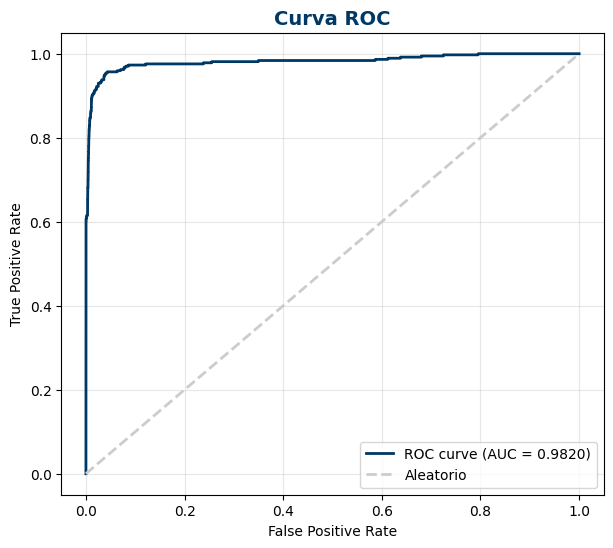

ROC AUC Score: 0.9820


In [43]:
fpr, tpr, thresholds = roc_curve(y_eval, y_proba_eval)
roc_auc_eval = roc_auc_score(y_eval, y_proba_eval)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color=ufd_blue, lw=2, label=f"ROC curve (AUC = {roc_auc_eval:.4f})")
plt.plot([0, 1], [0, 1], color=ufd_gray, lw=2, linestyle="--", label="Aleatorio")

# Estilo
plt.grid(alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC", fontsize=14, weight="bold", color=ufd_blue)
plt.legend(loc="lower right", fontsize=10)
plt.show()

print(f"ROC AUC Score: {roc_auc_eval:.4f}")

Mostramos también las curvas de ganancia y lift a continuación

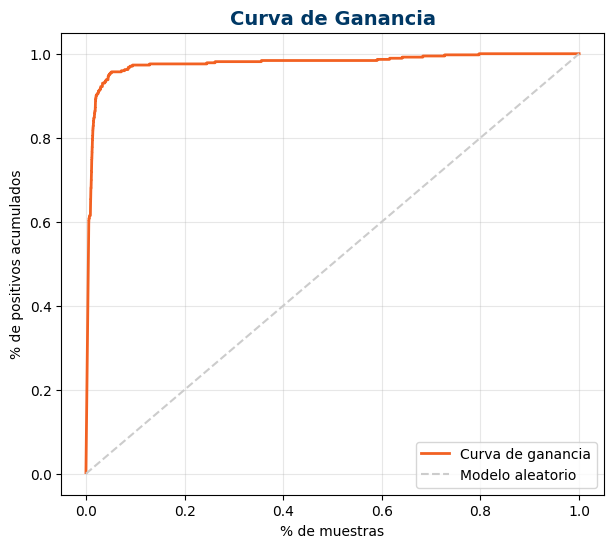

In [44]:
plot_gain(y_eval, y_proba_eval)

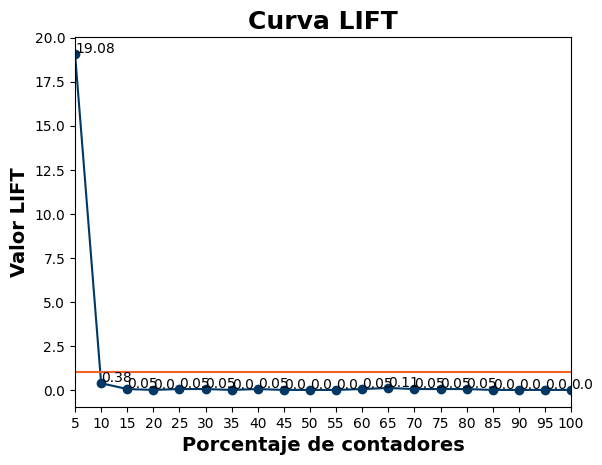

In [45]:
lift_chart_plot(y_eval, y_proba_eval, num_chunks=20)

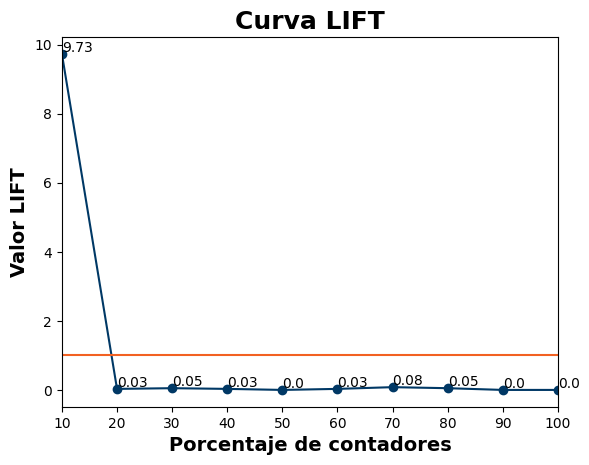

In [46]:
lift_chart_plot(y_eval, y_proba_eval, num_chunks=10)

## 5.4. Explainability

Let's make a global shap plot, in order to understand how the model gives predictions

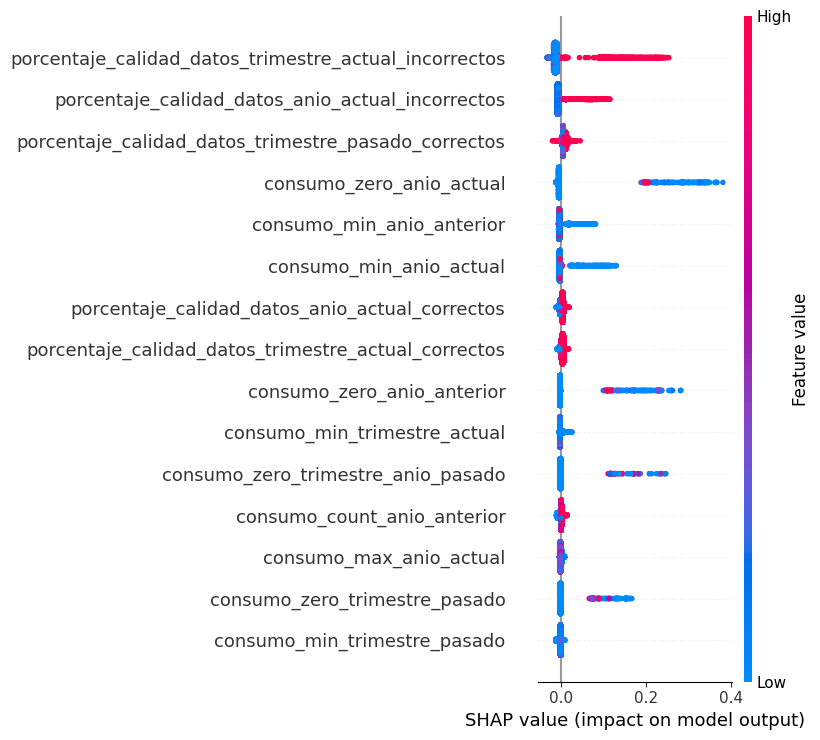

In [47]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_eval)

shap.summary_plot(shap_values[:,:,1], X_eval, max_display=15)

In [48]:
final_df_eval

,cups_sgc,cnt_id,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,...,lof_scores,lof_probabilities,anomaly_svm,svm_scores,svm_probabilities,anomaly_dbscan,fraude_score_no_supervisado,pred_proba,final_scoring,categoria_fraude
0,ES0022000001001149LS1P,SAG0185746454,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.002154,1.503011e-08,1,50.494923,1.000000e+00,0,0.4,0.017124,0.131987,Bajo
1,ES0022000001001381YV1P,SAG0186400186,0.0,0.0,0.0,0.0,0.0,28.0,0.0,0.0,...,1.496002,1.245491e-07,1,34.316814,1.000000e+00,0,0.4,0.084282,0.178997,Alto
2,ES0022000001001663LT1P,ZIV0036507981,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.435980,1.112382e-07,1,22.964204,1.000000e+00,0,0.4,0.018749,0.133124,Bajo
3,ES0022000001001684LK1P,SAG0185758532,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.0,...,1.087117,3.387199e-08,1,47.472426,1.000000e+00,0,0.4,0.018435,0.132905,Bajo
4,ES0022000001002173HG1P,SAG0145168555,0.0,0.0,0.0,0.0,27.0,0.0,27.0,28.0,...,1.432928,1.105615e-07,1,52.740596,1.000000e+00,0,0.4,0.020890,0.134623,Bajo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39752,ES0397000007990335SY1P,SOG0040011802,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.0,...,1.101905,3.715150e-08,1,42.647845,1.000000e+00,0,0.4,0.011485,0.128040,Bajo
39753,ES0397000008193106ED1P,ZIV0042493723,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.336300,8.913254e-08,1,41.679983,1.000000e+00,0,0.4,0.043999,0.150799,Alto
39754,ES0397000008258806AK1P,ZIV0044282168,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.100534,3.684754e-08,-1,-17.469613,2.588472e-08,0,0.0,0.057002,0.039902,Bajo
39755,ES0397000008265874NM1P,SAG0221810666,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.992591,1.290938e-08,1,42.120692,1.000000e+00,0,0.4,0.048149,0.153704,Alto


In [49]:
df_shap_eval = final_df_eval[["cups_sgc", "cnt_id"]].join(X_eval, how="right")
df_shap_eval.head(5)

,cups_sgc,cnt_id,porcentaje_calidad_datos_trimestre_actual_incorrectos,consumo_zero_anio_anterior,consumo_zero_anio_actual,porcentaje_calidad_datos_anio_actual_incorrectos,consumo_zero_mes_anio_pasado,consumo_zero_mes_actual,consumo_zero_trimestre_anio_pasado,consumo_min_anio_actual,...,consumo_stddev_trimestre_anio_pasado,porcentaje_calidad_datos_mes_actual_incorrectos,consumo_suma_mes_anio_pasado,consumo_max_trimestre_pasado,consumo_stddev_semana_pasada,consumo_suma_mes_pasado,consumo_stddev_semana_anio_pasado,consumo_max_semana_pasada,cnt_inspecciones_anio_actual,consumo_umbral_mes_actual
0,ES0022000001001149LS1P,SAG0185746454,0.00,0.0,0.0,0.02,0.0,0.0,0.0,30.0,...,257.51,0.00,225181.0,2160.0,237.01,226274.0,261.01,1795.0,84.0,723.0
1,ES0022000001001381YV1P,SAG0186400186,0.07,0.0,0.0,0.22,0.0,0.0,0.0,116.0,...,2080.78,0.13,785158.0,11599.0,2458.33,1000000.0,327.95,9477.0,0.0,743.0
2,ES0022000001001663LT1P,ZIV0036507981,0.00,0.0,0.0,0.07,0.0,0.0,0.0,197.0,...,0.00,0.00,0.0,5231.0,118.89,740032.0,0.00,797.0,54.0,744.0
3,ES0022000001001684LK1P,SAG0185758532,0.00,0.0,0.0,0.02,0.0,0.0,0.0,1.0,...,262.37,0.00,71186.0,1730.0,26.90,35273.0,283.06,169.0,28.0,22.0
4,ES0022000001002173HG1P,SAG0145168555,0.00,0.0,0.0,0.00,0.0,0.0,0.0,3.0,...,59.93,0.00,129935.0,3860.0,430.04,319236.0,28.92,1775.0,82.0,732.0


In [50]:
# Pasamos shap_values a DataFrame
df_shap_local = pd.DataFrame(shap_values[:, :, 1], columns=X_eval.columns)

# Añadimos las predicciones y el identificador
df_local_explain = pd.DataFrame({
    "cups_sgc": df_shap_eval["cups_sgc"], 
    "cnt_id": df_shap_eval["cnt_id"], 
    "prediction": model.predict_proba(X_eval)[:,1]
})

# 3. Pasamos a formato largo (para Power BI)
df_shap_long = df_shap_local.reset_index().melt(
    id_vars="index",
    var_name="feature",
    value_name="shap_value"
)

# 4. Unimos con los identificadores y predicciones
df_explain_final = df_shap_long.merge(
    df_local_explain.reset_index(),
    on="index"
).drop(columns=["index"])

df_explain_final["abs_shap_value"] = df_explain_final["shap_value"].abs()
# Esto lo exportas a CSV y lo cargas en Power BI
df_explain_final.to_csv("../powerbi/shap_local_explain.csv", index=False, decimal=",", sep=";")


In [51]:
pd.read_csv("../powerbi/shap_local_explain.csv", sep=";")

,feature,shap_value,cups_sgc,cnt_id,prediction,abs_shap_value
0,porcentaje_calidad_datos_trimestre_actual_inco...,"-0,013098781620341867",ES0022000001001149LS1P,SAG0185746454,"0,017124370924241464","0,013098781620341867"
1,porcentaje_calidad_datos_trimestre_actual_inco...,"-0,024575156782747874",ES0022000001001381YV1P,SAG0186400186,"0,08428171564094432","0,024575156782747874"
2,porcentaje_calidad_datos_trimestre_actual_inco...,"-0,012464911047091083",ES0022000001001663LT1P,ZIV0036507981,"0,018748537865148986","0,012464911047091083"
3,porcentaje_calidad_datos_trimestre_actual_inco...,"-0,012973597350583165",ES0022000001001684LK1P,SAG0185758532,"0,018435291465092332","0,012973597350583165"
4,porcentaje_calidad_datos_trimestre_actual_inco...,"-0,014100552108779146",ES0022000001002173HG1P,SAG0145168555,"0,020889969502760244","0,014100552108779146"
...,...,...,...,...,...,...
2981770,consumo_umbral_mes_actual,"-1,1568039178926605e-05",ES0397000007990335SY1P,SOG0040011802,"0,011485331088391715","1,1568039178926605e-05"
2981771,consumo_umbral_mes_actual,"-2,986168937850899e-07",ES0397000008193106ED1P,ZIV0042493723,"0,0439991939741024","2,986168937850899e-07"
2981772,consumo_umbral_mes_actual,"1,7096387153277573e-05",ES0397000008258806AK1P,ZIV0044282168,"0,057002348069860063","1,7096387153277573e-05"
2981773,consumo_umbral_mes_actual,"-7,400385661419485e-06",ES0397000008265874NM1P,SAG0221810666,"0,04814906096732928","7,400385661419485e-06"


## 5.7. Dashboard data extraction

In [52]:
columnas_considerar_preds = ["cups_sgc", "cnt_id", "fraude_score_no_supervisado", 
                             "pred_proba", "final_scoring", "categoria_fraude"]

In [53]:
grid_contadores_control = pd.read_csv(INPUT_GRID_CONTADORES_CONTROL_PATH_ABRIL)
grid_contadores_fraude = pd.read_csv(INPUT_GRID_CONTADORES_FRAUDE_PATH_ABRIL)

df_grid_contadores = pd.concat([grid_contadores_control, grid_contadores_fraude])

# Convertir a numérico (si hay valores raros, los pone como NaN)
df_grid_contadores["coord_utm_x_bdi"] = pd.to_numeric(df_grid_contadores["coord_utm_x_bdi"], errors="coerce")
df_grid_contadores["coord_utm_y_bdi"] = pd.to_numeric(df_grid_contadores["coord_utm_y_bdi"], errors="coerce")

# Crear transformador (UTM zona 30N -> WGS84)
transformer = Transformer.from_crs("EPSG:25830", "EPSG:4326", always_xy=True)

# Transformar coordenadas (saltará NaN si alguna fila no tenía valores válidos)
df_grid_contadores["longitud"], df_grid_contadores["latitud"] = transformer.transform(
    df_grid_contadores["coord_utm_x_bdi"].values,
    df_grid_contadores["coord_utm_y_bdi"].values
)

# df_grid_contadores.to_csv("coordenadas_contadores_lat_long.csv", index=False, decimal=",", sep=";")

NameError: name 'INPUT_GRID_CONTADORES_CONTROL_PATH_ABRIL' is not defined

In [ ]:
df_grid_contadores

NameError: name 'df_grid_contadores' is not defined

In [ ]:
(
    final_df_eval[columnas_considerar_preds]
    .merge(df_grid_contadores, how="left", on=["cups_sgc", "cnt_id"])
    .to_csv("powerbi/predicciones_cups.csv", index=False, sep=";", decimal=",")
)

NameError: name 'df_grid_contadores' is not defined

In [ ]:
def lift_at_percentile(y_true, y_proba, percentile=0.1):
    """
    Calcula el Lift en el top X% (percentile en [0,1]).
    """
    n = int(len(y_proba) * percentile)
    # Ordenar por probabilidad descendente
    idx = np.argsort(y_proba)[::-1]
    y_sorted = np.array(y_true)[idx]
    
    # Positivos en el top %
    top_positives = y_sorted[:n].sum()
    total_positives = y_sorted.sum()
    
    perc_total = top_positives / total_positives
    perc_samples = n / len(y_true)
    
    lift = perc_total / perc_samples
    return lift, perc_total

def compute_metrics(y_true, y_proba, dataset_name="test"):
    auc = roc_auc_score(y_true, y_proba)
    gini = 2 * auc - 1
    ks = ks_stat(y_true, y_proba)
    lift10, capture10 = lift_at_percentile(y_true, y_proba, 0.1)
    lift20, capture20 = lift_at_percentile(y_true, y_proba, 0.2)

    return {
        "dataset": dataset_name,
        "auc": round(auc, 3),
        "gini": round(gini, 3),
        "ks": round(ks, 3),
        "lift_at_10": lift10,
        "capture_rate_10": capture10,
        "lift_at_20": lift20,
        "capture_rate_20": capture20
    }

# =====================
# Calcular métricas train y test
# =====================
metrics_train = compute_metrics(y, y_proba, dataset_name="train")
metrics_test = compute_metrics(y_eval, y_proba_eval, dataset_name="test")

model_metrics = pd.DataFrame([metrics_train, metrics_test])

model_metrics.to_csv("powerbi/model_metrics.csv", index=False, sep=";", decimal=",")

In [ ]:
model_metrics

,dataset,auc,gini,ks,lift_at_10,capture_rate_10,lift_at_20,capture_rate_20
0,train,0.997,0.994,0.960,9.835453,0.983404,4.964438,0.992888
1,test,0.917,0.833,0.718,7.696654,0.769665,4.235115,0.847023


In [ ]:
fpr, tpr, thresholds = roc_curve(y_eval, y_proba)

roc_data = pd.DataFrame({
    "fpr": fpr,
    "tpr": tpr,
    "threshold": thresholds
})
roc_data.to_csv("powerbi/roc_curve.csv", index=False, sep=";", decimal=",")

ValueError: Found input variables with inconsistent numbers of samples: [36300, 34925]

In [ ]:
data = list(zip(y_eval, y_proba_eval))
data = sorted(data, key=lambda x: x[1], reverse=True)
y_sorted = np.array([d[0] for d in data])

cum_gains = np.cumsum(y_sorted) / sum(y_sorted)
perc_samples = np.arange(1, len(y_sorted)+1) / len(y_sorted)

gain_data = pd.DataFrame({
    "perc_samples": perc_samples,
    "cum_gains": cum_gains
})
gain_data.to_csv("powerbi/gain_curve.csv", index=False, sep=";", decimal=",")

In [ ]:
def compute_lift(y_true, y_proba, bins=20):
    data = list(zip(y_true, y_proba))
    data = sorted(data, key=lambda x: x[1], reverse=True)
    y_sorted = np.array([d[0] for d in data])

    total_rate = sum(y_sorted) / len(y_sorted)
    group_size = len(y_sorted) // bins
    lift_values, percentiles = [], []

    for i in range(bins):
        start = i * group_size
        end = (i+1) * group_size if i < bins-1 else len(y_sorted)
        group = y_sorted[start:end]
        group_rate = sum(group) / len(group)
        lift = group_rate / total_rate
        lift_values.append(lift)
        percentiles.append(100 - (i+1)*(100//bins))  # de 100 a 0

    return pd.DataFrame({
        "percentil": percentiles,
        "lift": lift_values
    })

lift_data = compute_lift(y_test, y_proba, bins=20)
lift_data.to_csv("powerbi/lift_curve.csv", index=False, sep=";", decimal=",")